# **Prediksi Kekuatan Tekan Beton Berdasarkan Komposisi Material untuk Optimasi Kualitas Konstruksi**

# Import Library

In [ ]:
# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk pra-pemrosesan data (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Mengatur tampilan plot agar lebih rapi
%matplotlib inline
sns.set(style="whitegrid")

# (Opsional) Library untuk evaluasi model (agar siap digunakan nanti)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Library berhasil di-import!")

Library berhasil di-import!


# Load Dataset

In [ ]:
df = pd.read_excel('Concrete_Data.xls')
print("Dataset berhasil dimuat")

Dataset berhasil dimuat


# Exploratory Data Analysis (EDA)

## Menampilkan 10 baris pertama

In [ ]:
df.head(10)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


## Dimensi Dataset

In [ ]:
print(f"Dimensi Dataset (baris, kolom): {df.shape}")

Dimensi Dataset (baris, kolom): (1030, 9)


## Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

## Statistik Deskriptif

In [ ]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## Distribusi Data (Histogram)

Visualisasi distribusi data menggunakan histogram bertujuan untuk melihat apakah data tersebar secara merata atau tidak, sehingga dapat diketahui apakah data bersifat seimbang (*balance*) atau tidak seimbang (*imbalance*). Histogram menampilkan jumlah data pada setiap rentang nilai dalam bentuk batang, di mana batang yang lebih tinggi menunjukkan jumlah data yang lebih banyak pada rentang tersebut. Selain batang, terdapat kurva yang disebut sebagai garis distribusi (*density line*) yang menunjukkan pola sebaran data secara lebih halus. Puncak pada garis tersebut menunjukkan rentang nilai dengan jumlah data terbanyak, sedangkan bagian yang landai menunjukkan jumlah data yang lebih sedikit. Jika garis distribusi berbentuk simetris dan tidak condong ke satu sisi, maka data cenderung seimbang. Sebaliknya, jika garis terlihat miring atau memiliki puncak yang sangat tinggi pada satu area tertentu, maka data cenderung tidak seimbang. Dengan melihat tinggi batang histogram dan bentuk garis distribusi tersebut, dapat dipahami bagaimana penyebaran data dan potensi pengaruhnya terhadap performa model.

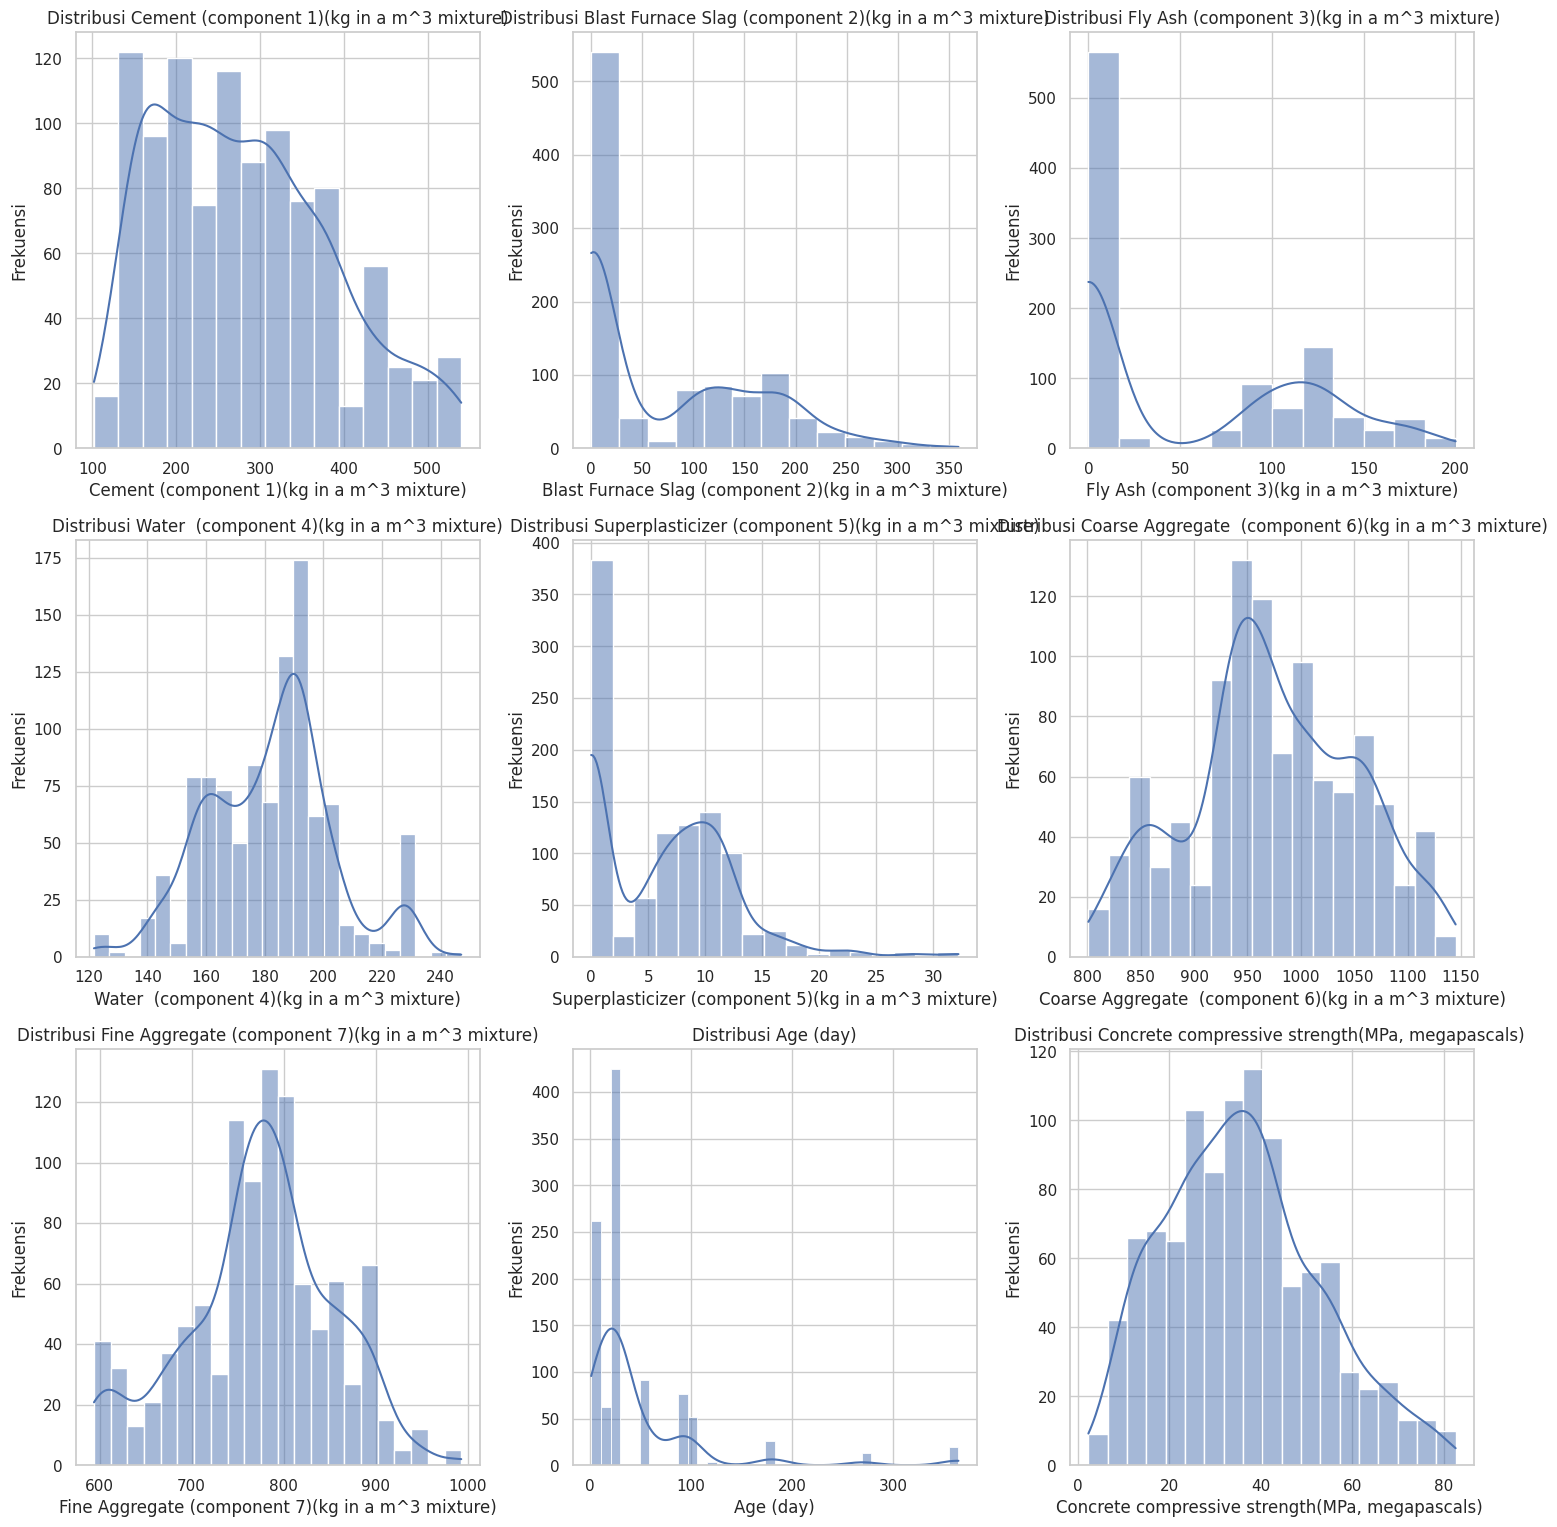

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih kolom numerik untuk visualisasi distribusi
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Membuat histogram untuk setiap kolom numerik
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(round(len(numerical_cols)/3) + 1, 3, i + 1) # Menyesuaikan layout subplot
    sns.histplot(df[col], kde=True) # kde=True untuk menampilkan estimasi kepadatan kernel
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

## Hubungan Antara Fitur dan Target (Scatter Plot)

Scatter plot digunakan untuk melihat hubungan antara masing-masing fitur dengan variabel target, yaitu kekuatan tekan beton. Visualisasi ini membantu memahami pola hubungan, apakah bersifat linear, non-linear, atau tidak memiliki hubungan yang jelas. Setiap titik pada grafik merepresentasikan satu data, sehingga dapat terlihat bagaimana perubahan nilai suatu fitur mempengaruhi nilai target. Garis yang ditampilkan pada scatter plot biasanya merupakan garis tren (*trend line*) atau garis regresi yang menunjukkan arah hubungan antara fitur dan target, di mana garis yang naik menunjukkan hubungan positif dan garis yang menurun menunjukkan hubungan negatif. Dengan scatter plot, dapat diidentifikasi fitur yang memiliki pengaruh kuat terhadap kekuatan beton, serta membantu mendeteksi pola, tren, atau kemungkinan adanya outlier dalam data. Insight yang diperoleh dari visualisasi ini dapat digunakan untuk mendukung proses pemodelan dan meningkatkan kualitas analisis.

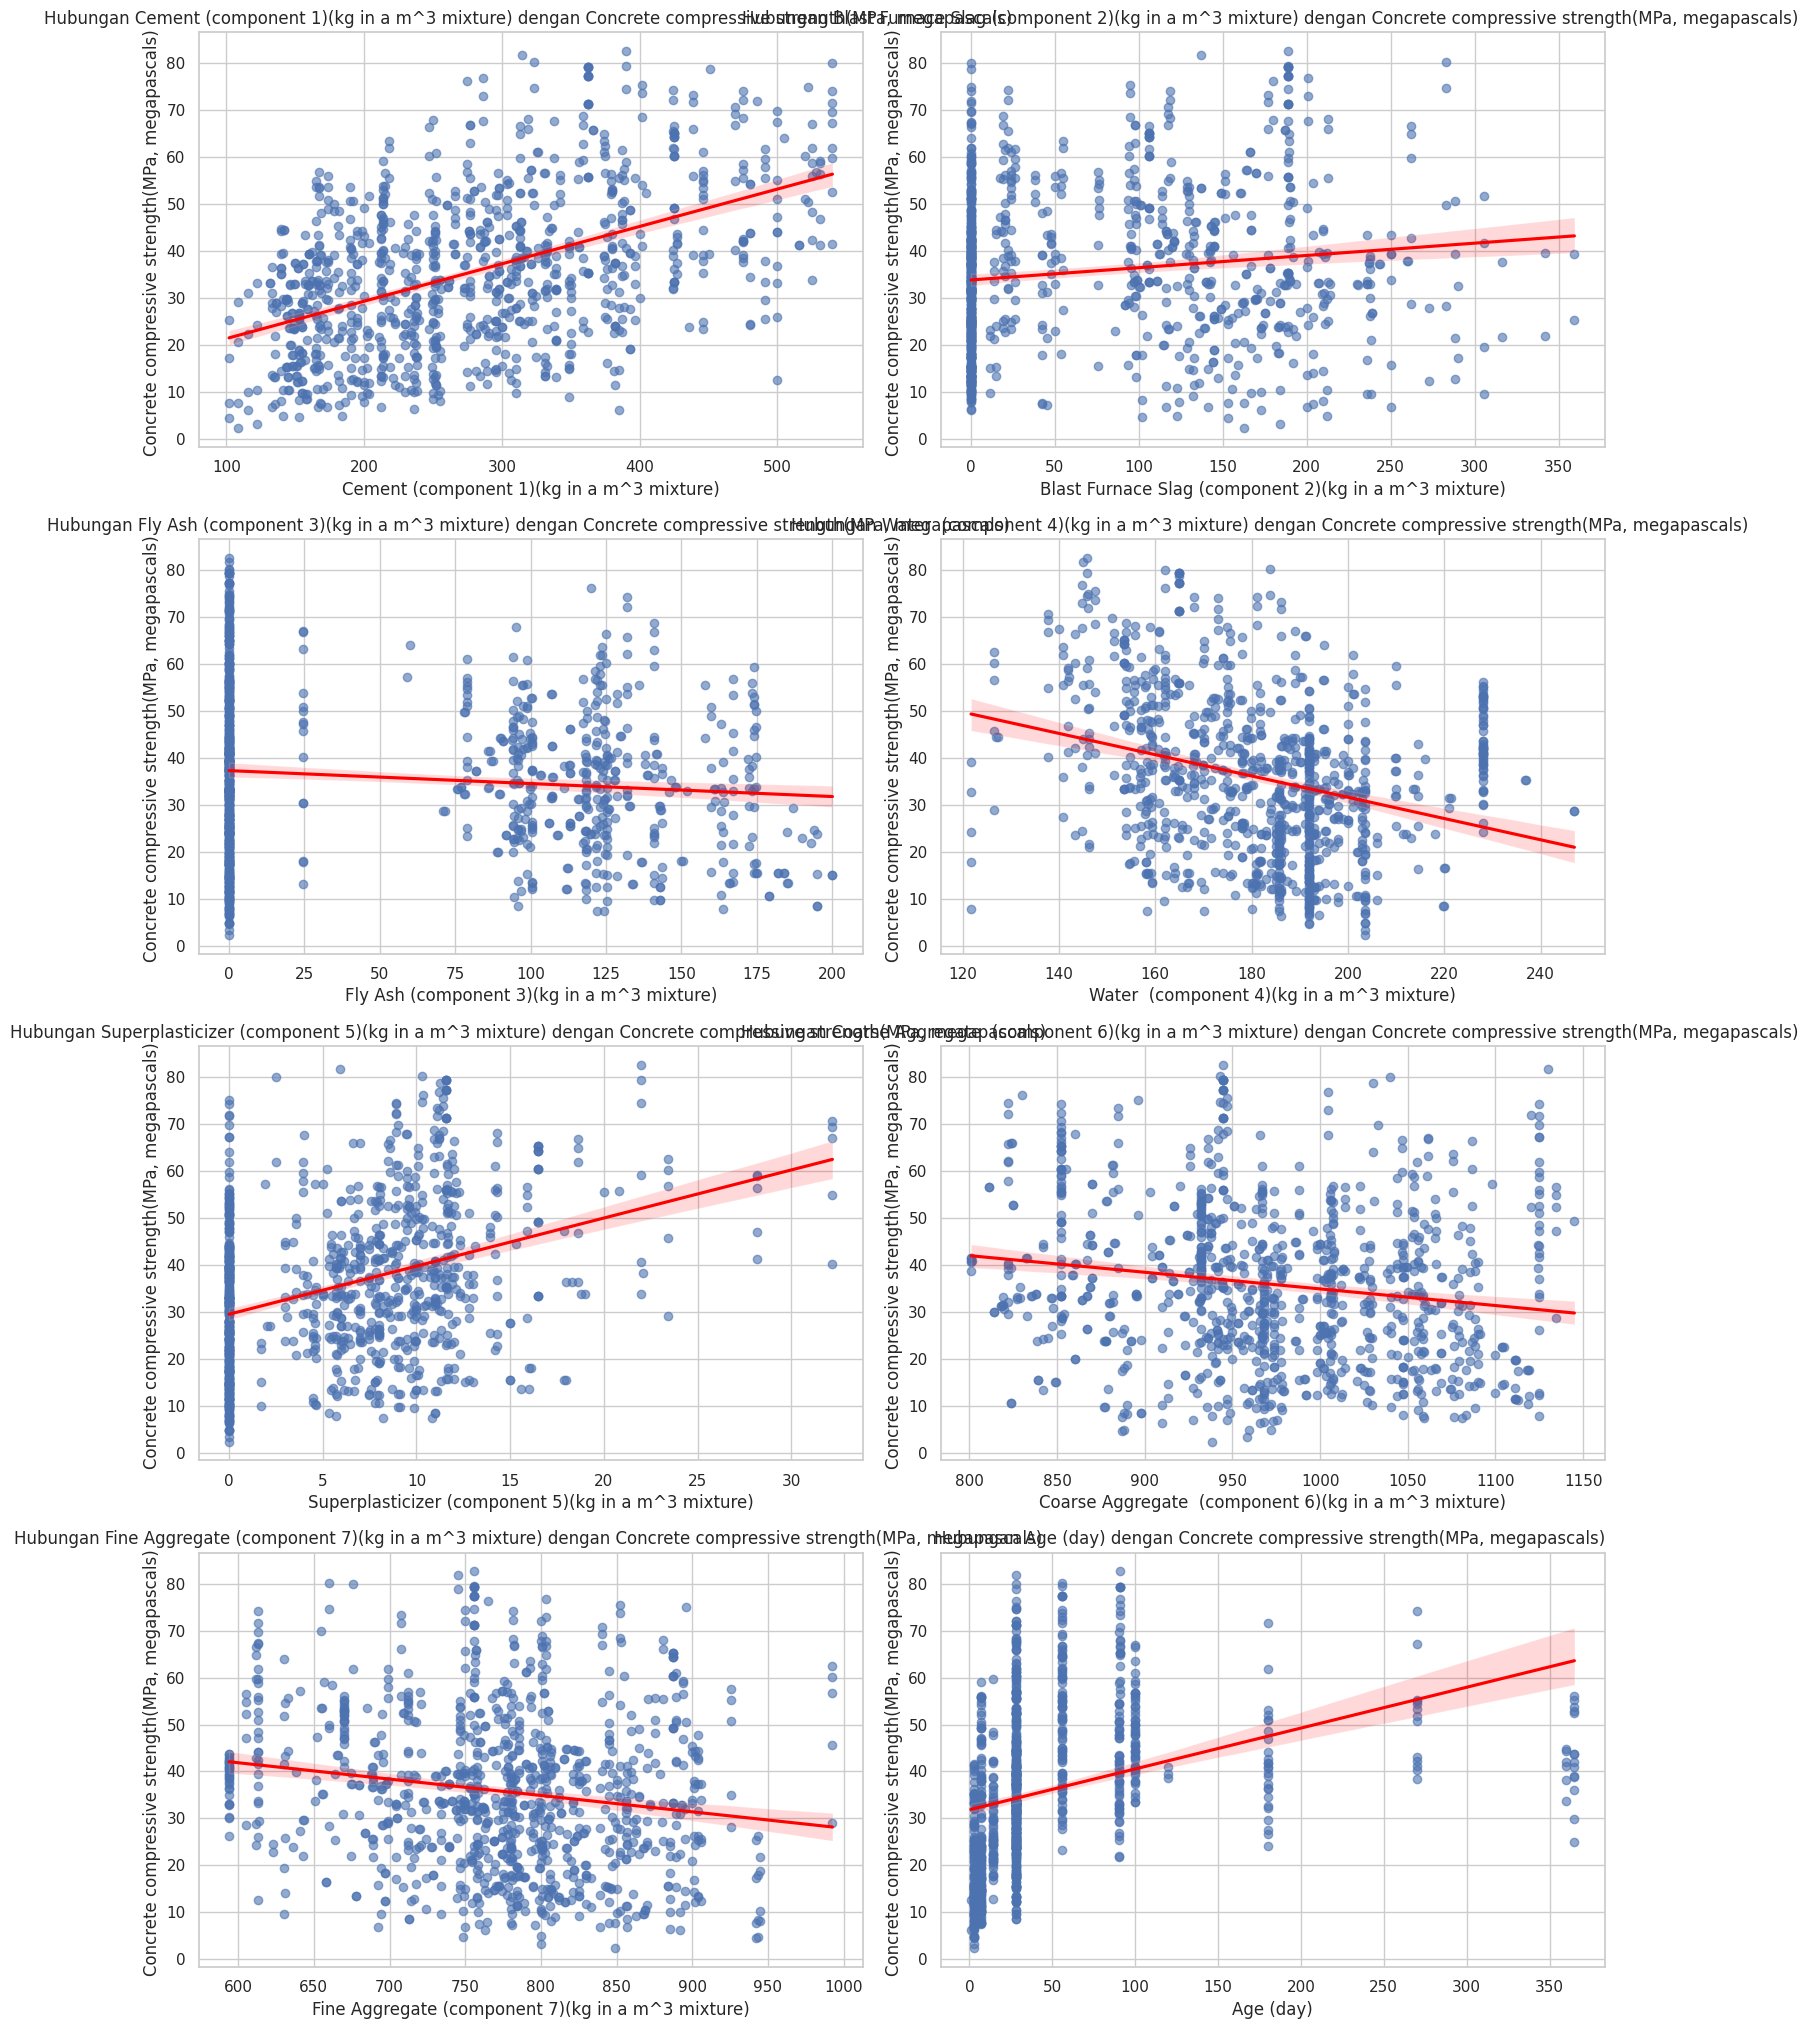

In [ ]:
target_col = 'Concrete compressive strength(MPa, megapascals) '
feature_cols = [col for col in df.select_dtypes(include=np.number).columns if col != target_col]

plt.figure(figsize=(15, 25))
for i, col in enumerate(feature_cols):
    plt.subplot(round(len(feature_cols)/2) + 1, 2, i + 1)
    sns.regplot(x=df[col], y=df[target_col], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Hubungan {col} dengan {target_col}')
    plt.xlabel(col)
    plt.ylabel(target_col)
plt.tight_layout()
plt.show()

## Korelasi Antar Variabel (Correlation Heatmap)

Korelasi antar variabel digunakan untuk mengetahui hubungan antara setiap fitur dalam dataset serta hubungannya dengan variabel target. Visualisasi *correlation heatmap* membantu menunjukkan seberapa kuat hubungan antar variabel, baik positif maupun negatif. Nilai korelasi berkisar antara -1 hingga 1, di mana nilai mendekati 1 menunjukkan hubungan positif yang kuat, nilai mendekati -1 menunjukkan hubungan negatif yang kuat, dan nilai mendekati 0 menunjukkan tidak adanya hubungan yang signifikan. Dengan melihat heatmap, dapat diketahui fitur mana yang paling berpengaruh terhadap kekuatan tekan beton, sehingga membantu dalam memahami pola data dan mendukung proses pemodelan *Machine Learning*.

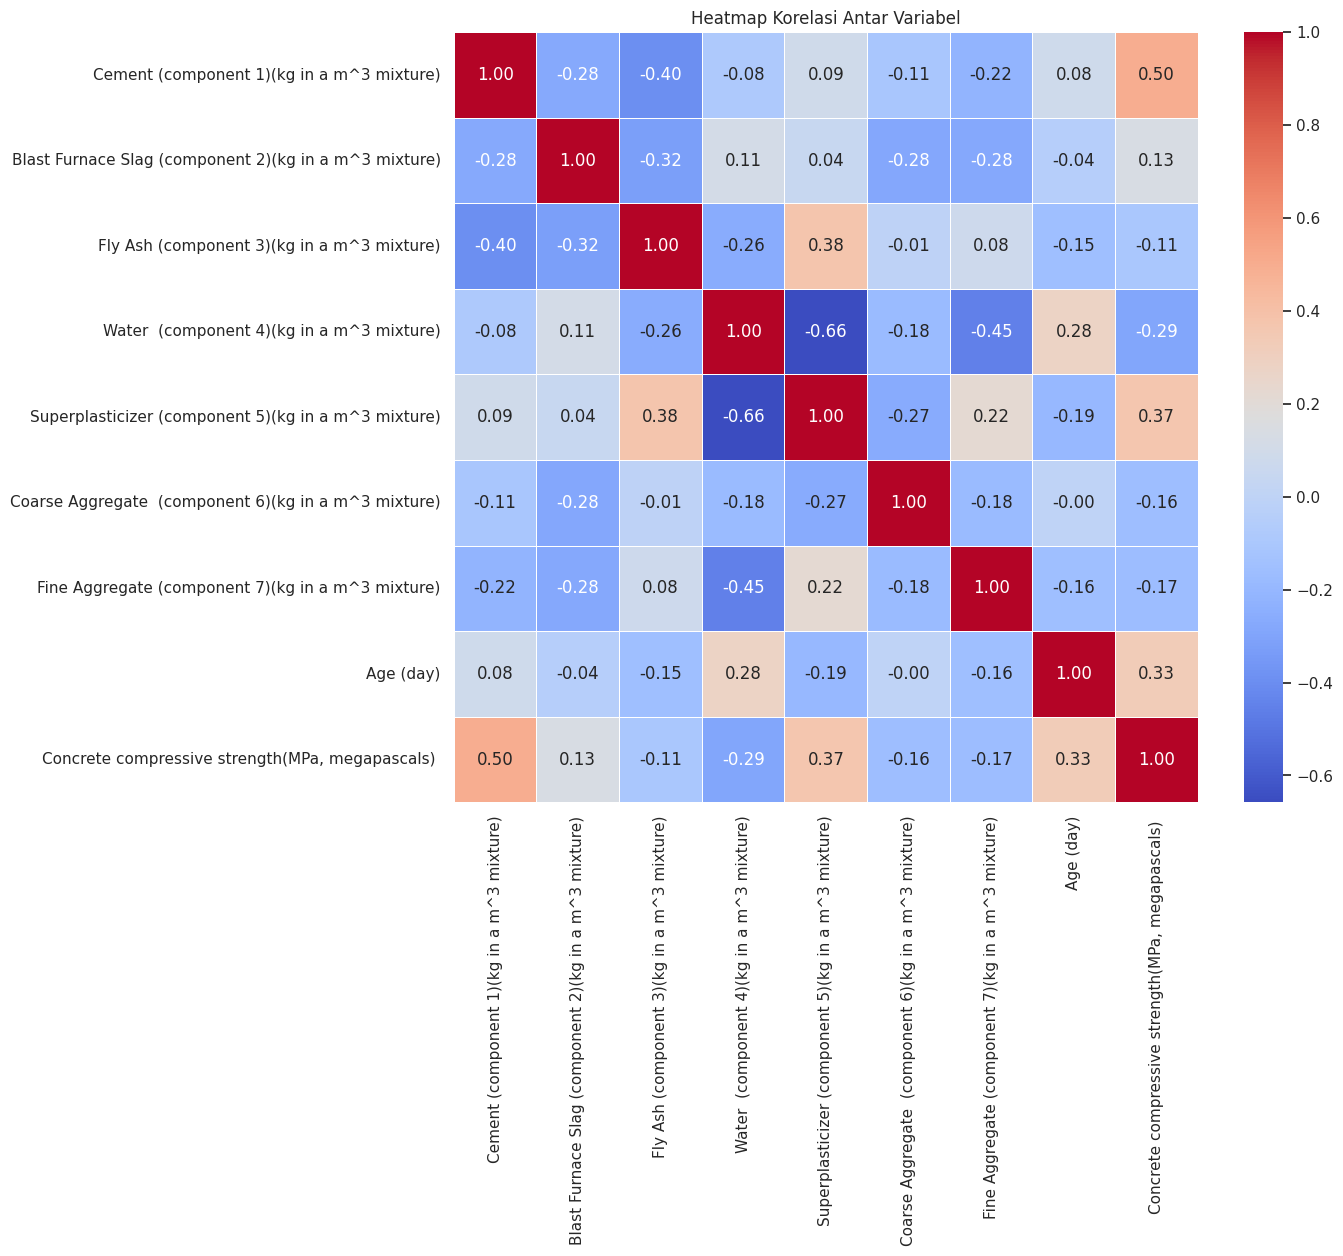

In [ ]:
# Menghitung matriks korelasi
corr_matrix = df.corr()

# Membuat heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

## Mengecek Nilai Kosong (Missing Values)

In [ ]:
print("Jumlah nilai kosong per kolom:")
print(df.isnull().sum())

Jumlah nilai kosong per kolom:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


### Mengecek Data Duplikat

In [ ]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah entri data yang berulang (duplikat): {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("\nContoh baris duplikat pertama:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
else:
    print("Tidak ditemukan entri data duplikat.")

Jumlah entri data yang berulang (duplikat): 25

Contoh baris duplikat pertama:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.691435
809,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.691435
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.895819
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.895819
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.895819
129,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.298713


# Data Preprocessing

## Menghapus Data Duplikat

In [ ]:
print(f"Dimensi DataFrame sebelum penghapusan duplikat: {df.shape}")

df_cleaned = df.drop_duplicates(keep='first')

print(f"Dimensi DataFrame setelah penghapusan duplikat: {df_cleaned.shape}")
print(f"Jumlah entri duplikat yang tersisa: {df_cleaned.duplicated().sum()}")

df = df_cleaned.copy() # Memperbarui DataFrame asli dengan data yang sudah dibersihkan

Dimensi DataFrame sebelum penghapusan duplikat: (1030, 9)
Dimensi DataFrame setelah penghapusan duplikat: (1005, 9)
Jumlah entri duplikat yang tersisa: 0


## Deteksi Outliers Menggunakan Boxplot

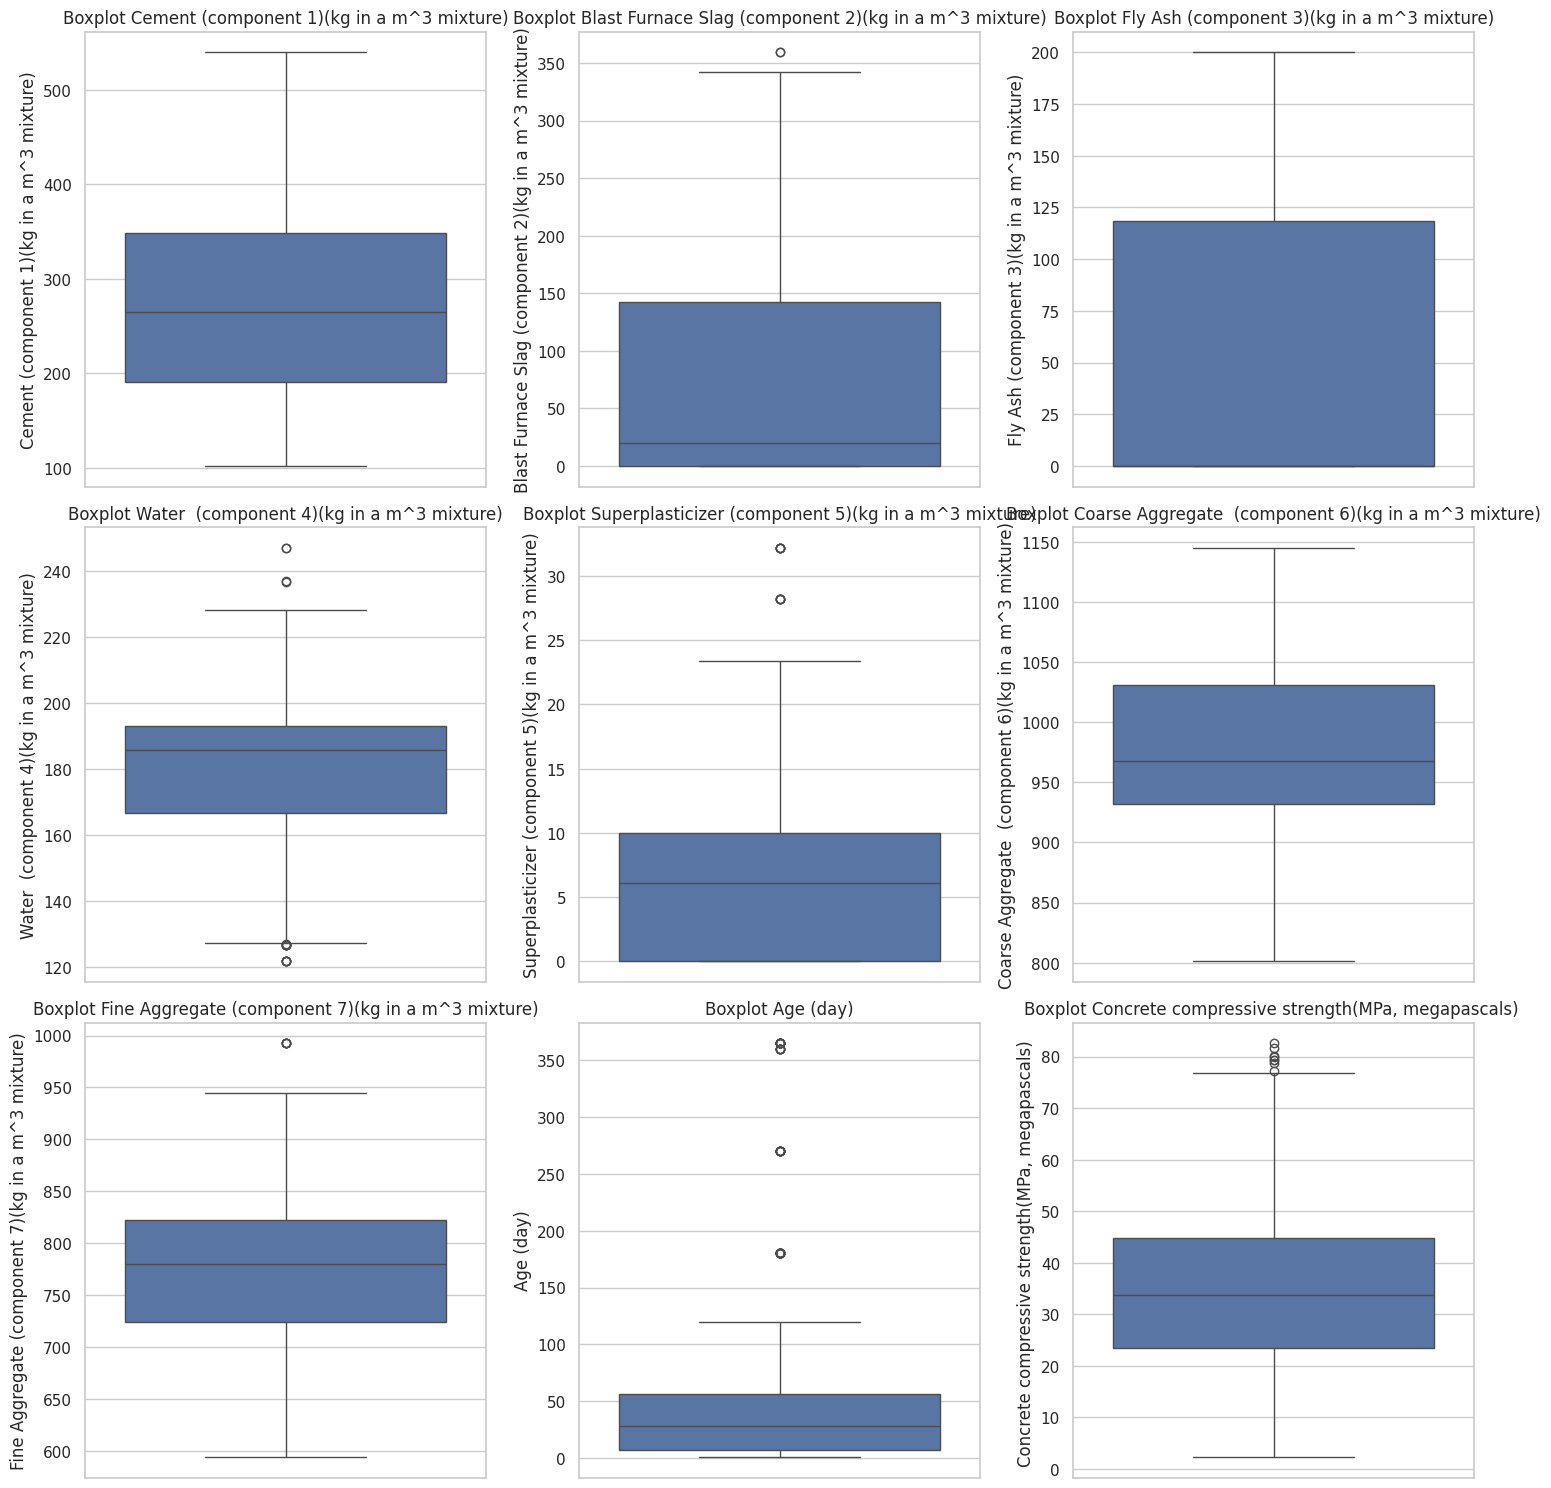

In [ ]:
# Memilih kolom numerik untuk visualisasi boxplot
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Membuat boxplot untuk setiap kolom numerik
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(round(len(numerical_cols)/3) + 1, 3, i + 1) # Menyesuaikan layout subplot
    sns.boxplot(y=df[col]) # Menggunakan y untuk boxplot vertikal
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Kuantifikasi Outlier Menggunakan Metode IQR

Untuk mengkuantifikasi jumlah outlier, kita akan menggunakan metode Interquartile Range (IQR). Outlier didefinisikan sebagai titik data yang berada di bawah `Q1 - 1.5 * IQR` atau di atas `Q3 + 1.5 * IQR`.

In [ ]:
outlier_counts = {}
total_outliers = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Menghitung outlier untuk setiap kolom
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)
    total_outliers += len(outliers)

print("Jumlah Outlier per Fitur (menggunakan metode IQR):")
for col, count in outlier_counts.items():
    print(f"- {col}: {count} outlier")

print(f"\nTotal jumlah outlier di seluruh fitur: {total_outliers}")

# Menampilkan baris yang mengandung outlier (opsional, untuk inspeksi)
# if total_outliers > 0:
#     print("\nContoh baris yang mengandung outlier:")
#     outlier_rows = pd.DataFrame()
#     for col in numerical_cols:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - (1.5 * IQR)
#         upper_bound = Q3 + (1.5 * IQR)
#         outlier_rows = pd.concat([outlier_rows, df[(df[col] < lower_bound) | (df[col] > upper_bound)]])
#     display(outlier_rows.drop_duplicates().head())


Jumlah Outlier per Fitur (menggunakan metode IQR):
- Cement (component 1)(kg in a m^3 mixture): 0 outlier
- Blast Furnace Slag (component 2)(kg in a m^3 mixture): 2 outlier
- Fly Ash (component 3)(kg in a m^3 mixture): 0 outlier
- Water  (component 4)(kg in a m^3 mixture): 15 outlier
- Superplasticizer (component 5)(kg in a m^3 mixture): 10 outlier
- Coarse Aggregate  (component 6)(kg in a m^3 mixture): 0 outlier
- Fine Aggregate (component 7)(kg in a m^3 mixture): 5 outlier
- Age (day): 59 outlier
- Concrete compressive strength(MPa, megapascals) : 8 outlier

Total jumlah outlier di seluruh fitur: 99


## Penanganan Outlier Menggunakan Capping (Winsorization)

Setelah mengidentifikasi outlier, langkah selanjutnya adalah menanganinya. Salah satu metode yang efektif, terutama dalam konteks *machine learning*, adalah *capping* atau *Winsorization*. Metode ini bertujuan untuk membatasi nilai-nilai ekstrem tanpa menghapus baris data sepenuhnya, sehingga mempertahankan informasi yang mungkin relevan.

### Cara Kerja Capping (Metode IQR):

1.  **Hitung IQR**: Sama seperti deteksi outlier, kita menghitung *Interquartile Range* (IQR) untuk setiap kolom numerik.
2.  **Tentukan Batas Atas dan Bawah**: Batas bawah dihitung sebagai `Q1 - (1.5 * IQR)` dan batas atas sebagai `Q3 + (1.5 * IQR)`.
3.  **Capping**: Semua nilai yang lebih rendah dari batas bawah akan diganti dengan nilai batas bawah tersebut, dan semua nilai yang lebih tinggi dari batas atas akan diganti dengan nilai batas atas tersebut.

In [ ]:
# Menerapkan capping pada kolom-kolom yang terdeteksi memiliki outlier
df_capped = df.copy() # Buat salinan DataFrame untuk menghindari modifikasi DataFrame asli

print("Menerapkan capping pada fitur-fitur dengan outlier...")

# Kolom yang diidentifikasi memiliki outlier dari analisis sebelumnya
columns_with_outliers = [
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
    'Water  (component 4)(kg in a m^3 mixture)',
    'Superplasticizer (component 5)(kg in a m^3 mixture)',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)',
    'Age (day)',
    'Concrete compressive strength(MPa, megapascals) '
]

for col in columns_with_outliers:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Terapkan capping
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
    print(f"- Kolom '{col}' telah di-capping.")

df = df_capped.copy() # Memperbarui DataFrame asli dengan data yang sudah di-capping
print("\nProses capping selesai. Berikut adalah statistik deskriptif setelah penanganan outlier:")
df.describe()

Menerapkan capping pada fitur-fitur dengan outlier...
- Kolom 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)' telah di-capping.
- Kolom 'Water  (component 4)(kg in a m^3 mixture)' telah di-capping.
- Kolom 'Superplasticizer (component 5)(kg in a m^3 mixture)' telah di-capping.
- Kolom 'Fine Aggregate (component 7)(kg in a m^3 mixture)' telah di-capping.
- Kolom 'Age (day)' telah di-capping.
- Kolom 'Concrete compressive strength(MPa, megapascals) ' telah di-capping.

Proses capping selesai. Berikut adalah statistik deskriptif setelah penanganan outlier:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.036866,55.535075,182.066075,5.979905,974.376468,772.569453,38.076119,35.226147
std,104.345003,86.149742,64.207448,21.161153,5.724027,77.579534,80.035346,35.862549,16.220078
min,102.000000,0.000000,0.000000,127.115000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,356.250000,200.100000,232.435000,25.000000,1145.000000,969.050000,129.500000,76.885537


## Standarisasi Fitur Menggunakan `StandardScaler`

Standarisasi fitur dilakukan untuk menyamakan skala seluruh variabel agar tidak ada fitur yang mendominasi proses pembelajaran model *Machine Learning*. Proses ini penting karena setiap fitur memiliki satuan dan rentang nilai yang berbeda, sehingga dapat mempengaruhi hasil prediksi jika tidak disesuaikan. Metode `StandardScaler` digunakan untuk mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1, yang berarti nilai data dipusatkan di sekitar nol dengan tingkat penyebaran yang sama. Dengan kondisi ini, model dapat belajar secara lebih stabil dan seimbang terhadap semua fitur. Standarisasi dilakukan sebelum proses training dan juga diterapkan pada data baru saat inference agar konsisten dengan kondisi saat model dilatih.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Memisahkan fitur (X) dan variabel target (y)
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df['Concrete compressive strength(MPa, megapascals) ']

print("Fitur (X) dan target (y) berhasil dipisahkan.")
print(f"Bentuk X: {X.shape}")
print(f"Bentuk y: {y.shape}")

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan standarisasi pada fitur X
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame untuk kemudahan inspeksi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData fitur telah berhasil distandarisasi menggunakan StandardScaler.")
print("Statistik deskriptif setelah standarisasi (contoh 5 baris pertama):")
display(X_scaled_df.head())

Fitur (X) dan target (y) berhasil dipisahkan.
Bentuk X: (1005, 8)
Bentuk y: (1005,)

Data fitur telah berhasil distandarisasi menggunakan StandardScaler.
Statistik deskriptif setelah standarisasi (contoh 5 baris pertama):


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,2.506120,-0.836598,-0.865363,-0.948723,-0.608250,0.846308,-1.207186,-0.281105
1,2.506120,-0.836598,-0.865363,-0.948723,-0.608250,1.039755,-1.207186,-0.281105
2,0.516534,0.818322,-0.865363,2.171753,-1.045223,-0.546505,-2.232243,2.550555
3,0.516534,0.818322,-0.865363,2.171753,-1.045223,-0.546505,-2.232243,2.550555
4,-0.767348,0.701026,-0.865363,0.469675,-1.045223,0.051889,0.661669,2.550555


# Data Splitting
Data splitting merupakan proses membagi dataset menjadi data training dan data testing untuk melatih dan mengevaluasi model *Machine Learning*. Data training digunakan untuk melatih model agar dapat mempelajari pola dari data, sedangkan data testing digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya. Pada penelitian ini digunakan beberapa variasi pembagian data, yaitu 50:50, 60:40, 70:30, 80:20, dan 90:10, untuk mengetahui pengaruh proporsi data terhadap performa model. Penggunaan beberapa rasio ini bertujuan untuk memastikan bahwa model yang dihasilkan tidak hanya bergantung pada satu pembagian data saja, sehingga hasil evaluasi menjadi lebih objektif dan dapat dipercaya.

In [ ]:
from sklearn.model_selection import train_test_split

# Definisikan rasio test_size yang diinginkan
test_sizes = [0.5, 0.4, 0.3, 0.2, 0.1] # Sesuai dengan 50:50, 60:40, 70:30, 80:20, 90:10

# Dictionary untuk menyimpan hasil splitting
data_splits = {}

print("Melakukan data splitting untuk berbagai rasio:\n")

for test_size in test_sizes:
    train_ratio = 1 - test_size
    key = f"train_{int(train_ratio*100)}_test_{int(test_size*100)}"

    # Lakukan splitting
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)

    # Simpan hasilnya dalam dictionary
    data_splits[key] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

    print(f"Rasio {int(train_ratio*100)}:{int(test_size*100)}:")
    print(f"  Bentuk X_train: {X_train.shape}")
    print(f"  Bentuk X_test: {X_test.shape}")
    print(f"  Bentuk y_train: {y_train.shape}")
    print(f"  Bentuk y_test: {y_test.shape}\n")

print("Semua data telah berhasil dibagi.\n")
print("Anda dapat mengakses setiap set data melalui dictionary 'data_splits'.")
print("Contoh: data_splits['train_80_test_20']['X_train'].shape")

Melakukan data splitting untuk berbagai rasio:

Rasio 50:50:
  Bentuk X_train: (502, 8)
  Bentuk X_test: (503, 8)
  Bentuk y_train: (502,)
  Bentuk y_test: (503,)

Rasio 60:40:
  Bentuk X_train: (603, 8)
  Bentuk X_test: (402, 8)
  Bentuk y_train: (603,)
  Bentuk y_test: (402,)

Rasio 70:30:
  Bentuk X_train: (703, 8)
  Bentuk X_test: (302, 8)
  Bentuk y_train: (703,)
  Bentuk y_test: (302,)

Rasio 80:20:
  Bentuk X_train: (804, 8)
  Bentuk X_test: (201, 8)
  Bentuk y_train: (804,)
  Bentuk y_test: (201,)

Rasio 90:10:
  Bentuk X_train: (904, 8)
  Bentuk X_test: (101, 8)
  Bentuk y_train: (904,)
  Bentuk y_test: (101,)

Semua data telah berhasil dibagi.

Anda dapat mengakses setiap set data melalui dictionary 'data_splits'.
Contoh: data_splits['train_80_test_20']['X_train'].shape


# Model Building dan Evaluasi

Pada tahap ini dilakukan pembangunan model *Machine Learning* menggunakan tiga algoritma, yaitu CatBoost, XGBoost, dan LightGBM, yang merupakan algoritma berbasis *gradient boosting*. XGBoost (*Extreme Gradient Boosting*) diperkenalkan sekitar tahun 2016 dan bekerja dengan membangun model secara bertahap untuk memperbaiki kesalahan dari model sebelumnya dengan teknik optimasi yang efisien. LightGBM (*Light Gradient Boosting Machine*) diperkenalkan oleh Microsoft pada tahun 2017 dan menggunakan pendekatan berbasis *leaf-wise tree growth* yang membuat proses training lebih cepat dan efisien pada data besar. CatBoost (*Categorical Boosting*) dikembangkan oleh Yandex pada tahun 2018 dan dirancang untuk mengatasi bias serta overfitting dengan teknik pengolahan data yang lebih stabil. Ketiga algoritma ini bekerja dengan cara membangun banyak pohon keputusan secara bertahap, di mana setiap model baru berusaha memperbaiki kesalahan model sebelumnya. Setelah model dibangun, dilakukan evaluasi menggunakan metrik seperti MAE, MSE, RMSE, dan R² untuk mengukur tingkat kesalahan dan akurasi model. Hasil evaluasi kemudian dibandingkan untuk menentukan model dengan performa terbaik dalam memprediksi kekuatan tekan beton.

In [ ]:
!pip install catboost xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
# Import library yang BELUM ada (sesuaikan jika sudah pernah import)
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Fungsi evaluasi
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Inisialisasi model
models = {
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42)
}

# List untuk menyimpan hasil
results = []

print("===== MODEL BUILDING & EVALUASI =====\n")

# Loop melalui setiap hasil splitting
for split_name, split_data in data_splits.items():
    print(f"\n=== {split_name} ===")

    X_train = split_data['X_train']
    X_test = split_data['X_test']
    y_train = split_data['y_train']
    y_test = split_data['y_test']

    for model_name, model in models.items():
        # Training
        model.fit(X_train, y_train)

        # Prediksi
        y_pred = model.predict(X_test)

        # Evaluasi
        mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

        # Simpan hasil
        results.append({
            "Split": split_name,
            "Model": model_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        })

        print(f"{model_name}")
        print(f"  MAE  : {mae:.4f}")
        print(f"  MSE  : {mse:.4f}")
        print(f"  RMSE : {rmse:.4f}")
        print(f"  R2   : {r2:.4f}\n")

# DataFrame hasil akhir
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

print("\n===== RINGKASAN HASIL (TOP PERFORMA) =====")
display(results_df)

===== MODEL BUILDING & EVALUASI =====


=== train_50_test_50 ===
CatBoost
  MAE  : 3.0856
  MSE  : 22.1191
  RMSE : 4.7031
  R2   : 0.9203

XGBoost
  MAE  : 3.3787
  MSE  : 23.8743
  RMSE : 4.8861
  R2   : 0.9140

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 502, number of used features: 8
[LightGBM] [Info] Start training from score 34.495263
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost
  MAE  : 2.9498
  MSE  : 22.3388
  RMSE : 4.7264
  R2   : 0.9220

XGBoost
  MAE  : 3.3217
  MSE  : 24.3286
  RMSE : 4.9324
  R2   : 0.9151

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 764
[LightGBM] [Info] Number of data points in the train set: 603, number of used features: 8
[LightGBM] [Info] Start training from score 34.417794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM
  MAE  : 3.3967
  MSE  : 24.1408
  RMSE : 4.9133
  R2   : 0.9157


=== train_70_test_30 ===
CatBoost
  MAE  : 2.8330
  MSE  : 20.6517
  RMSE : 4.5444
  R2   : 0.9268

XGBoost
  MAE  : 3.0987
  MSE  : 21.8010
  RMSE : 4.6692
  R2   : 0.9227

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 873
[LightGBM] [Info] Number of data points in the train set: 703, number of used features: 8
[LightGBM] [Info] Start training from score 35.035281
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

...

CatBoost
  MAE  : 2.4387
  MSE  : 15.6329
  RMSE : 3.9538
  R2   : 0.9465

XGBoost
  MAE  : 2.7874
  MSE  : 20.5914
  RMSE : 4.5378
  R2   : 0.9295

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 804, number of used features: 8
[LightGBM] [Info] Start training from score 35.054445
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost
  MAE  : 2.6274
  MSE  : 15.8381
  RMSE : 3.9797
  R2   : 0.9333

XGBoost
  MAE  : 2.6185
  MSE  : 17.4690
  RMSE : 4.1796
  R2   : 0.9265

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 904, number of used features: 8
[LightGBM] [Info] Start training from score 34.927889
LightGBM
  MAE  : 3.2669
  MSE  : 22.4036
  RMSE : 4.7332
  R2   : 0.9057


===== RINGKASAN HASIL (TOP PERFORMA) =====


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Split,Model,MAE,MSE,RMSE,R2 Score
9,train_80_test_20,CatBoost,2.438673,15.632874,3.953843,0.946493
11,train_80_test_20,LightGBM,2.990942,18.390778,4.288447,0.937054
12,train_90_test_10,CatBoost,2.627448,15.838143,3.979717,0.933342
10,train_80_test_20,XGBoost,2.787430,20.591440,4.537779,0.929521
6,train_70_test_30,CatBoost,2.832964,20.651688,4.544413,0.926788
13,train_90_test_10,XGBoost,2.618517,17.468968,4.179589,0.926478
7,train_70_test_30,XGBoost,3.098705,21.800980,4.669152,0.922714
3,train_60_test_40,CatBoost,2.949835,22.338805,4.726394,0.922035
0,train_50_test_50,CatBoost,3.085552,22.119136,4.703099,0.920287
5,train_60_test_40,LightGBM,3.396705,24.140836,4.913332,0.915746


# Hyperparameter Tuning menggunakan `RandomizedSearchCV` pada CatBoost

Hyperparameter tuning dilakukan untuk mencari kombinasi parameter terbaik agar model dapat menghasilkan performa yang optimal. Proses ini penting karena parameter seperti jumlah iterasi, learning rate, dan kedalaman pohon sangat mempengaruhi kemampuan model dalam belajar dari data. Pada penelitian ini digunakan metode `RandomizedSearchCV`, yaitu teknik pencarian parameter secara acak dari beberapa kemungkinan nilai yang telah ditentukan. Metode ini lebih efisien dibandingkan mencoba seluruh kombinasi parameter karena hanya mengambil sejumlah sampel kombinasi tertentu, sehingga dapat menghemat waktu komputasi. Selain itu, digunakan teknik *cross-validation* untuk memastikan bahwa hasil evaluasi model lebih stabil dan tidak bergantung pada satu pembagian data saja. Proses ini menghasilkan model terbaik dengan kombinasi parameter yang mampu memberikan performa paling tinggi, sehingga meningkatkan akurasi prediksi kekuatan tekan beton.

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

# Ambil data terbaik
split_data = data_splits['train_80_test_20']
X_train = split_data['X_train']
X_test = split_data['X_test']
y_train = split_data['y_train']
y_test = split_data['y_test']

# Parameter search space
param_dist = {
    'iterations': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 0.5, 1, 2]
}

# Model dasar
cat = CatBoostRegressor(verbose=0, random_state=42)

# Random Search
random_search = RandomizedSearchCV(
    cat,
    param_distributions=param_dist,
    n_iter=20,  # bisa dinaikkan jadi 50 kalau mau lebih optimal
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Training
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Evaluasi
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Best Params:", random_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))

Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 6, 'bagging_temperature': 1}
R2 Score: 0.9462499727599117


# Evaluasi Awal Model Hasil Hyperparameter Tuning

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2.44967123820873
MSE : 15.703901460347282
RMSE: 3.9628148405328356
R2  : 0.9462499727599117


# Optimasi Model dengan `Early Stopping` dan `Over-Iteration`
Optimasi model dilakukan untuk meningkatkan performa prediksi serta mencegah terjadinya *overfitting*. Teknik *over-iteration* dilakukan dengan meningkatkan jumlah iterasi agar model dapat belajar lebih banyak pola dari data, sehingga peluang untuk menghasilkan prediksi yang lebih akurat menjadi lebih besar. Namun, terlalu banyak iterasi dapat menyebabkan model terlalu menyesuaikan data training sehingga performa pada data baru menurun. Untuk mengatasi hal tersebut, digunakan teknik *early stopping*, yaitu metode untuk menghentikan proses training lebih awal jika tidak ada peningkatan performa dalam beberapa iterasi. Dengan cara ini, model akan berhenti pada titik performa terbaik tanpa harus menyelesaikan seluruh iterasi yang ditentukan, sehingga menghasilkan model yang lebih optimal dan memiliki kemampuan generalisasi yang baik.

In [ ]:
final_model = CatBoostRegressor(
    iterations=2000,            # naikkan jauh
    learning_rate=0.03,         # kecilkan
    depth=6,                    # bisa coba 6–8
    l2_leaf_reg=3,
    early_stopping_rounds=100,
    verbose=0,
    random_state=42
)

final_model.fit(X_train, y_train, eval_set=(X_test, y_test))

y_pred = final_model.predict(X_test)

from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.9503957957601071


# Evaluasi Akhir dan Pembaruan Hasil Model Terbaik

In [ ]:
# Ambil split 80:20
split_name = 'train_80_test_20'
split_data = data_splits[split_name]

X_train = split_data['X_train']
X_test = split_data['X_test']
y_train = split_data['y_train']
y_test = split_data['y_test']

# Prediksi pakai model terbaik
y_pred = final_model.predict(X_test)

# Hitung ulang metrik
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Hapus hasil lama CatBoost 80:20
results_df = results_df[
    ~((results_df['Split'] == split_name) & (results_df['Model'] == 'CatBoost'))
]

# Tambahkan hasil baru
new_row = pd.DataFrame([{
    "Split": split_name,
    "Model": "CatBoost (Tuned)",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)

# Urutkan ulang
results_df = results_df.sort_values(by="R2 Score", ascending=False)

# Tampilkan
display(results_df)

,Split,Model,MAE,MSE,RMSE,R2 Score
14,train_80_test_20,CatBoost (Tuned),2.290970,14.492635,3.806919,0.950396
0,train_80_test_20,LightGBM,2.990942,18.390778,4.288447,0.937054
1,train_90_test_10,CatBoost,2.627448,15.838143,3.979717,0.933342
2,train_80_test_20,XGBoost,2.787430,20.591440,4.537779,0.929521
3,train_70_test_30,CatBoost,2.832964,20.651688,4.544413,0.926788
4,train_90_test_10,XGBoost,2.618517,17.468968,4.179589,0.926478
5,train_70_test_30,XGBoost,3.098705,21.800980,4.669152,0.922714
6,train_60_test_40,CatBoost,2.949835,22.338805,4.726394,0.922035
7,train_50_test_50,CatBoost,3.085552,22.119136,4.703099,0.920287
8,train_60_test_40,LightGBM,3.396705,24.140836,4.913332,0.915746


# Visualisasi Perbandingan Performa Model

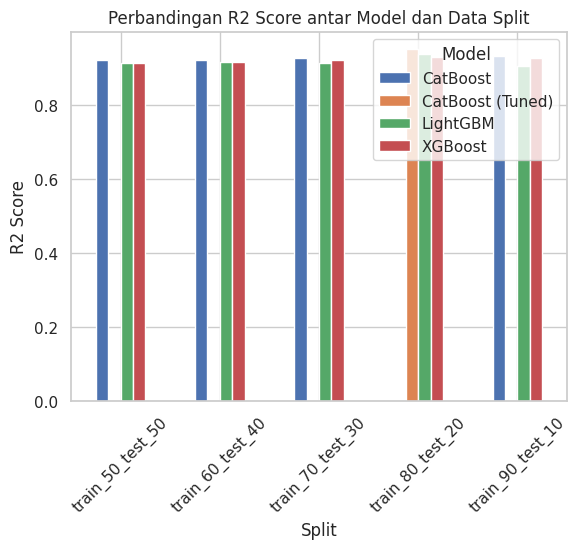

In [ ]:
import matplotlib.pyplot as plt

# Ambil R2 saja
pivot_table = results_df.pivot(index="Split", columns="Model", values="R2 Score")

pivot_table.plot(kind="bar")
plt.title("Perbandingan R2 Score antar Model dan Data Split")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

# Penyimpanan Model dan Scaler untuk Deployment

In [ ]:
import joblib

# Simpan model terbaik
joblib.dump(final_model, "catboost_model.pkl")

# Simpan scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Inference pada Machine Learning
Inference adalah proses menggunakan model *Machine Learning* yang sudah dilatih untuk membuat prediksi pada data baru. Pada tahap ini, model tidak lagi belajar, tetapi hanya menggunakan pola yang sudah dipelajari sebelumnya. Data baru yang dimasukkan harus memiliki format dan struktur yang sama seperti data saat training. Jika sebelumnya dilakukan standarisasi, maka data baru juga harus melalui proses yang sama sebelum diprediksi. Model kemudian mengolah data tersebut dan menghasilkan output berupa nilai prediksi. Hasil prediksi ini digunakan untuk membantu pengambilan keputusan berdasarkan data.  

In [ ]:
# Load model dan scaler yang sudah disimpan
model = joblib.load("catboost_model.pkl")
scaler = joblib.load("scaler.pkl")

# Contoh data baru (HARUS sesuai urutan fitur saat training)
data_baru = pd.DataFrame([{
    'Cement (component 1)(kg in a m^3 mixture)': 300,
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)': 50,
    'Fly Ash (component 3)(kg in a m^3 mixture)': 20,
    'Water  (component 4)(kg in a m^3 mixture)': 180,
    'Superplasticizer (component 5)(kg in a m^3 mixture)': 8,
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)': 1000,
    'Fine Aggregate (component 7)(kg in a m^3 mixture)': 750,
    'Age (day)': 28
}])

# Standarisasi data baru (WAJIB karena model dilatih pakai scaler)
data_baru_scaled = scaler.transform(data_baru)

# Prediksi
prediksi = model.predict(data_baru_scaled)

# Tampilkan hasil
print("Prediksi Kekuatan Tekan Beton (MPa):", prediksi[0])

Prediksi Kekuatan Tekan Beton (MPa): 39.79851243144669
